In [118]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit, int32,njit, prange
import networkx as nx
from scipy.special import erfc, gamma,comb,loggamma,gammaln
from tqdm import tqdm
import pickle
import time
import scipy.special as sc
import math
import random
from joblib import Parallel, delayed
from scipy.optimize import curve_fit
from scipy.stats import poisson
import scipy.stats as stats
from math import comb, factorial 
from functools import lru_cache



%matplotlib widget
plt.rcParams.update({
        "text.usetex": True,            # Use LaTeX for text rendering
        "font.family": "serif",         # Use a serif font
        "axes.linewidth": 1.5,          # Set axes line width
        "xtick.major.width": 0.3,       # Set x-axis major tick width
        "ytick.major.width": 0.3,       # Set y-axis major tick width
        "xtick.minor.width": 0.3,       # Set x-axis minor tick width
        "ytick.minor.width": 0.3,       # Set y-axis minor tick width
        "axes.labelsize": 18,           # Set label size for axes
        "legend.fontsize": 18,          # Set font size for legend
        "xtick.labelsize": 18,          # Set font size for x-axis labels
        "ytick.labelsize": 18,          # Set font size for y-axis labels
        "xtick.major.size": 3,          # Increase major tick size
        "ytick.major.size": 3,          # Increase major tick size
        "xtick.minor.size": 2,          # Increase minor tick size
        "ytick.minor.size": 2,          # Increase minor tick size
    })
for spine in plt.gca().spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

# --- Waiting time generator ---
@njit
def draw_waiting_time(distribution, lambda_, k, sigma, mu, alpha, x_m):
    if distribution == "exponential":
        return np.random.exponential(1 / lambda_)
    elif distribution == "weibull":
        return np.random.weibull(k) * lambda_
    elif distribution == "lognormal":
        return np.random.lognormal(mu, sigma)
    elif distribution == "pareto":
        return (np.random.pareto(alpha) + 1) * x_m
    elif distribution == "pareto1":
        return (np.random.pareto(alpha + 1) + 1) * x_m
    elif distribution == "pareto2":
        return (np.random.pareto(alpha + 2) + 1) * x_m
    else:
        raise ValueError("Invalid distribution")


def preprocess_graph(G):
    nodes = np.array(G.nodes(), dtype=np.int32)
    degrees = np.array([G.degree(node) for node in nodes], dtype=np.int32)
    E = np.sum(degrees) // 2
    all_neighbors = []
    offsets = [0]

    for node in nodes:
        neighbors = list(G.neighbors(node))
        all_neighbors.extend(neighbors)
        offsets.append(len(all_neighbors))

    edges_flat = np.array(all_neighbors, dtype=np.int32)
    offsets = np.array(offsets, dtype=np.int32)

    return nodes, degrees, edges_flat, offsets, E

@njit(parallel=True)
def simulate_distinct_counts(T, n_walkers, nodes, edges_flat, offsets, N, rate):
    counts = np.empty(n_walkers, dtype=np.int32)  # stores number of distinct sites per walker
    
    for i in prange(n_walkers):
        current = np.random.randint(N)  # random starting node
        current = 0
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        t = 0.0
        
        while True:
            tau = np.random.exponential(1.0 / rate)  # waiting time until next jump
            if t + tau > T:  # if next jump would exceed total time, stop
                break
            t += tau
            
            start, end = offsets[current], offsets[current + 1]
            if end > start:  # has neighbors
                current = edges_flat[start + np.random.randint(end - start)]
                visited[current] = 1
        
        counts[i] = np.sum(visited)  # total distinct visited sites
    
    return counts

@njit(parallel=True)
def simulate_distinct_counts_discrete(T, n_walkers, nodes, edges_flat, offsets, N):
    counts = np.empty(n_walkers, dtype=np.int32)  # stores number of distinct sites per walker
    
    for i in prange(n_walkers):
        #current = np.random.randint(N)  # random starting node
        current =0
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        
        for _ in range(T):  # exactly T steps
            start, end = offsets[current], offsets[current + 1]
            if end > start:  # has neighbors
                current = edges_flat[start + np.random.randint(end - start)]
                visited[current] = 1
        
        counts[i] = np.sum(visited)  # total distinct visited sites
    return counts

def CCP_discrete(N, T, s_max=None):
    if s_max is None:
        s_max = N
    probs = np.zeros(s_max+1)
    
    for S in range(1, s_max+1):
        stir = stirling2(T, S-1)
        if stir == 0:
            continue
        
        log_comb = gammaln(N) - gammaln(S) - gammaln(N-S+1)   # log(C(N-1, S-1))
        log_fact = gammaln(S)                                # log((S-1)!)
        log_stir = math.log(stir)
        log_denom = T * math.log(N-1)
        
        log_prob = log_comb + log_fact + log_stir - log_denom
        probs[S] = math.exp(log_prob)
    
    return probs

def CCP_distribution(N, rate, T, s_max=None, tol=1e-38):
    lamT = rate * T
    if s_max is None:
        s_max = N
    probs = np.zeros(s_max+1)
    # adaptive Poisson cutoff
    n_max = int(lamT + 50*np.sqrt(lamT))

    for S in range(1, s_max+1):
        total = 0.0
        for n in range(S-1, n_max+1):
            # Skip if Poisson weight already negligible
            Pn = stats.poisson.pmf(n, lamT)
            if Pn < tol:
                break

            stir = stirling2(n, S-1)
            if stir == 0:
                continue

            # log(prob_v) = log(C(N-1,S-1)) + log((S-1)!) + log(stir) - n*log(N-1)
            log_comb = gammaln(N) - gammaln(S) - gammaln(N-S+1)
            log_fact = gammaln(S)
            log_stir = math.log(stir)
            log_denom = n * math.log(N-1)

            log_prob_v = log_comb + log_fact + log_stir - log_denom
            prob_given_n = math.exp(log_prob_v)

            total += prob_given_n * Pn

        probs[S] = total

    return probs
def harmonic_number(n):
    return np.sum(1.0 / np.arange(1, n))


@lru_cache(None)
def stirling2(n, k):
    """Stirling number of the second kind S(n, k)."""
    if n == k == 0:
        return 1
    if n == 0 or k == 0:
        return 0
    if k > n:
        return 0
    return k * stirling2(n-1, k) + stirling2(n-1, k-1)

basepath = f"/home/sarvesh/large_deviation"

In [ ]:
#descrete waiting time
#figure 1




# Graph parameters
N = 100
p = 0.1

# Walker simulation parameters
n_walkers = 10**8
rate = 2.0  # λ=2 => ψ(τ) = 2 e^{-2τ}
T_fixed = 200
r,h=3,5
m=3
# Generate connected ER graph
while True:
    #G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,)
    #G = nx.cycle_graph(N)
    G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets, E = preprocess_graph(G)
N=len(nodes)
# Run discrete-time simulation
visited_counts = simulate_distinct_counts_discrete(T_fixed, n_walkers, nodes, edges_flat, offsets, N)

# Histogram from simulation
max_visits = max(visited_counts)
x = np.bincount(visited_counts, minlength=max_visits+1)
hist = x / np.sum(x)

# Analytical
P_ccp = CCP_discrete(N, T_fixed, max_visits)


np.save(f"{basepath}/data/fig_1_complete_network_N_{N}_t_{T_fixed}_rate_2_visited_counts_discrete.npy", visited_counts)
np.save(f"{basepath}/data/fig_1_complete_network_N_{N}_t_{T_fixed}_rate_2_histogram_discrete.npy", hist)
np.save(f"{basepath}/data/fig_1_complete_network_N_{N}_t_{T_fixed}_rate_2_P_ccp_discrete.npy", P_ccp)

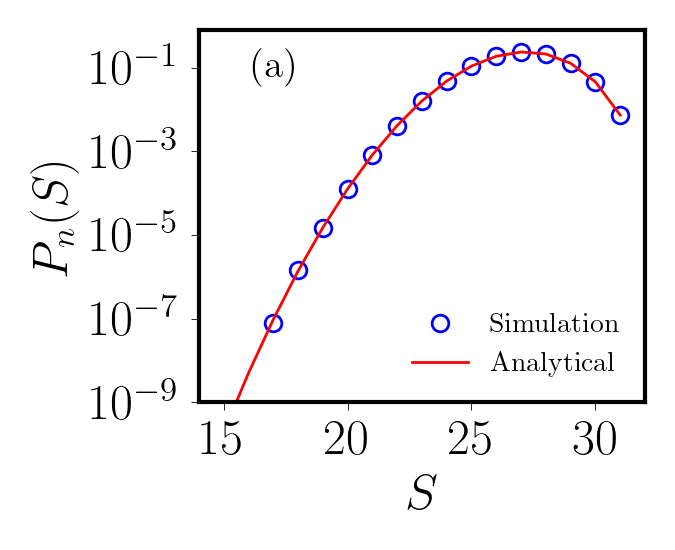

In [94]:
#figure 1 
T_fixed = 30   #T_fixed=30  for figure 1a  and T_fixed=200  for figure 1b
N=100
visited_counts=np.load(f"{basepath}/data/fig_1_complete_network_N_{N}_t_{T_fixed}_rate_2_visited_counts_discrete.npy")
hist=np.load(f"{basepath}/data/fig_1_complete_network_N_{N}_t_{T_fixed}_rate_2_histogram_discrete.npy")
P_ccp=np.load(f"{basepath}/data/fig_1_complete_network_N_{N}_t_{T_fixed}_rate_2_P_ccp_discrete.npy")

#plt.figure(figsize=(3.375, 2.5), dpi=200)
plt.figure(figsize=(3.375, 2.75), dpi=200)
ax=plt.gca()


plt.semilogy(np.arange(1, len(hist)), hist[1:], 'bo', mfc="none", label='Simulation')
plt.semilogy(np.arange(1, len(P_ccp)), P_ccp[1:], 'r-', label='Analytical', lw=1)
 #t=30
if T_fixed==30:
    
    plt.xticks([10,15,20,25,30,35])
    plt.yticks([.1,0.001,0.00001,.0000001,0.000000001])
    plt.xlim(14,32)
    plt.ylim(0.000000001,0.8)
    plt.text(0.12, 0.95, "(a)", transform=ax.transAxes, fontsize=14, va='top')

else:
    plt.xticks([70,80,90,100])
    plt.yticks([.1,0.001,0.00001,.0000001,0.000000001])
    plt.xlim(64,103)
    plt.ylim(0.000000001,0.8)
    plt.text(0.12, 0.95, "(b)", transform=ax.transAxes, fontsize=14, va='top')
plt.xlabel(r"$S$")
plt.ylabel(r"$P_n(S)$")
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

In [95]:

plt.savefig(f"./fig/complete_network_N_{N}_t_{T_fixed}_discrete.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [22]:
#figure 2 data  #T_fixed=1  for figure 1a  and T_fixed=50  for figure 1b
# Graph parameters
basepath = f"/home/sarvesh/large_deviation"
N = 1000
p = 0.01

# Walker simulation parameters
n_walkers = 10**8
rate = 2.0  # λ=2 => ψ(τ) = 2 e^{-2τ}
T_fixed = 1
r,h=3,5
m=3
# Generate connected ER graph
while True:
    #G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,)
    #G = nx.cycle_graph(N)
    G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets, E = preprocess_graph(G)
N=len(nodes)
visited_counts = simulate_distinct_counts(T_fixed, n_walkers, nodes, edges_flat, offsets, N, rate)


max_visits = max(visited_counts)
x=np.bincount(visited_counts,minlength=max_visits+1)
hist=x/np.sum(x)

v_vals = np.arange(1, max_visits + 1)
n_vals = v_vals-1

P_ccp = CCP_distribution(N, rate, T_fixed, max_visits)
np.save(f"{basepath}/data/fig_2_complete_network_N_{N}_t_{T_fixed}_rate_2_visited_counts.npy", visited_counts)
np.save(f"{basepath}/data/fig_2_complete_network_N_{N}_t_{T_fixed}_rate_2_histogram.npy", hist)
np.save(f"{basepath}/data/fig_2_complete_network_N_{N}_t_{T_fixed}_rate_2_P_ccp.npy", P_ccp)

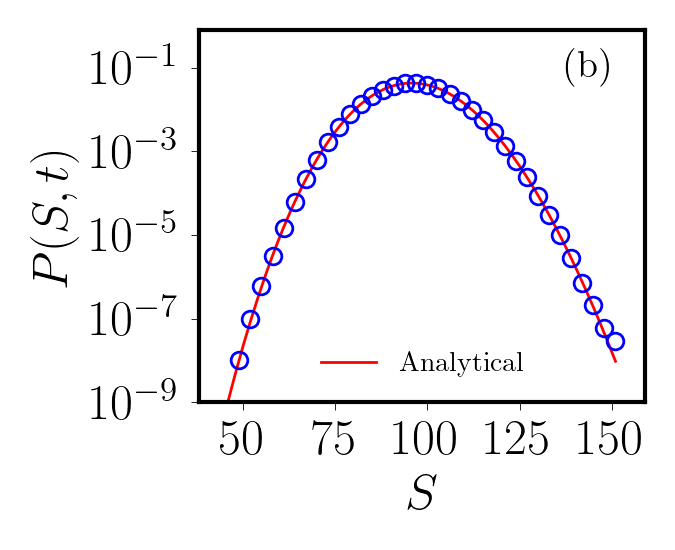

In [98]:
T_fixed=50 #T_fixed=1  for figure 2a  and T_fixed=50  for figure 2b
N=1000
visited_counts=np.load(f"{basepath}/data/fig_2_complete_network_N_{N}_t_{T_fixed}_rate_2_visited_counts.npy")
hist=np.load(f"{basepath}/data/fig_2_complete_network_N_{N}_t_{T_fixed}_rate_2_histogram.npy")
P_ccp=np.load(f"{basepath}/data/fig_2_complete_network_N_{N}_t_{T_fixed}_rate_2_P_ccp.npy")

#plt.figure(figsize=(3.375, 2.5),dpi=200)
#plt.figure(figsize=(3.675, 2.75), dpi=200)
plt.figure(figsize=(3.375, 2.75), dpi=200)
ax=plt.gca()
plt.semilogy(np.arange(1, len(P_ccp)), P_ccp[1:], 'r-', label='Analytical', lw=1)
#plt.semilogy(v_vals, P_analytical, 'r-', color='g', label=' (Poisson shifted)', lw=2)
plt.xlabel(r"$S$")
plt.ylabel("$P(S,t)$")
plt.legend(frameon=False,fontsize=10)
if T_fixed==1:
    plt.semilogy(np.arange(1, len(hist)), hist[1:], 'bo', mfc="none", label='Simulation')
    plt.xticks([0,5,10,15,20])
    plt.yticks([.1,0.001,0.00001,.0000001,0.000000001])
    plt.xlim(0,17)
    plt.ylim(0.000000001,0.8)
    plt.text(0.82, 0.95, "(a)", transform=ax.transAxes, fontsize=14, va='top')
else:
    plt.semilogy(np.arange(1, len(hist),3), hist[1::3], 'bo', mfc="none", label='Simulation')
    plt.xticks([50,75,100,125,150,175])
    plt.yticks([.1,0.001,0.00001,.0000001,0.000000001])
    plt.xlim(38,159)
    plt.ylim(0.000000001,0.8)
    plt.text(0.82, 0.95, "(b)", transform=ax.transAxes, fontsize=14, va='top')
plt.tight_layout()
plt.show()

In [99]:
plt.savefig(f"./fig/complete_network_N_{N}_t_{T_fixed}_rate_2.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [138]:
def generate_network(network_type, n=100, p=0.6, r=3, h=4, m=3, k=4, nc=[50, 50], seed=1234):
    rng = np.random.default_rng(seed)

    if network_type == 0:  # Fully Connected (FC)
        G = nx.complete_graph(n)

    elif network_type == 1:  # Erdős–Rényi (ER)
        while True:
            G = nx.erdos_renyi_graph(n, p, seed=int(rng.integers(1e9)))
            if nx.is_connected(G):
                break

    elif network_type == 2:  # Barabási–Albert (BA)
        while True:
            G = nx.barabasi_albert_graph(n, m, seed=int(rng.integers(1e9)))
            if nx.is_connected(G):
                break

    elif network_type == 3:  # Small-World (SW)
        while True:
            G = nx.watts_strogatz_graph(n, k, p, seed=int(rng.integers(1e9)))
            if nx.is_connected(G):
                break

    elif network_type == 4:  # Cayley Tree
        
        G = nx.balanced_tree(r, h)

    elif network_type == 5:  # Circular Network
        G = nx.cycle_graph(n)

    elif network_type == 6:  # Two-cluster
        clno = [0, *np.cumsum(nc)]
        G = complete_two_cluster_graph(n, nc, clno)

    else:
        raise ValueError("Invalid network type number")

    return G
@njit
def draw_waiting_time(distribution, lambda_, k, sigma, mu, alpha, x_m):
    if distribution == "exponential":
        return np.random.exponential(1 / lambda_)
    elif distribution == "weibull":
        return np.random.weibull(k) * lambda_
    elif distribution == "lognormal":
        return np.random.lognormal(mu, sigma)
    elif distribution == "pareto1":
        return (np.random.pareto(alpha+1) + 1) * x_m
    elif distribution == "pareto2":
        return (np.random.pareto(alpha+2) + 1) * x_m    
    elif distribution == "pareto":
        return (np.random.pareto(alpha) + 1) * x_m    
    elif distribution == "discrete":
        return 1.0
    else:
        return np.random.exponential(1 / lambda_)

def mean_waiting_time(distribution, lambda_=1.0, k=1.5, sigma=0.5, mu=0.0, alpha=2.5, x_m=1.0):
    """
    Return the mean waiting time ⟨τ⟩ for the given distribution.
    Parameters match those in draw_waiting_time.
    """
    if distribution == "exponential":
        return 1.0 / lambda_

    elif distribution == "weibull":
        # scale * Γ(1 + 1/k), here scale = λ
        return lambda_ * gamma(1.0 + 1.0 / k)

    elif distribution == "lognormal":
        # exp(μ + σ²/2)
        return exp(mu + 0.5 * sigma**2)

    elif distribution == "pareto":
        # standard Pareto mean = (α * xm) / (α - 1), requires α > 1
        return x_m * alpha / (alpha - 1) if alpha > 1 else np.inf

    elif distribution == "pareto1":
        # shape parameter (α+2), mean finite if α+2 > 1
        return x_m * (alpha + 1) / alpha if alpha + 1 > 1 else np.inf
    elif distribution == "pareto2":
        # same as pareto2 in your sampler
        return x_m * (alpha + 2) / (alpha + 1) if alpha + 2 > 1 else np.inf

    elif distribution == "discrete":
        return 1.0

    else:
        # default: exponential
        return 1.0 / lambda_
import numpy as np
from math import gamma, exp, inf

# ======================
# Cover time simulation
# ======================
@njit(parallel=True)
def simulate_cover_times(n_rounds, nodes, offsets, edges_flat, N,
                         distribution, lambda_, k, sigma, mu, alpha, x_m):
    cover_times = np.empty(n_rounds, dtype=np.float64)
    mean_waitings = np.empty(n_rounds, dtype=np.float64)
    for i in prange(n_rounds):
        current = np.random.randint(N)
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        distinct = 1
        t = 0.0
        tau_sum = 0.0
        tau_count = 0

        while distinct < N:
            tau = draw_waiting_time(distribution, lambda_, k, sigma, mu, alpha, x_m)
            t += tau
            tau_sum += tau
            tau_count += 1

            start, end = offsets[current], offsets[current + 1]
            current = edges_flat[start + np.random.randint(end - start)]
            if visited[current] == 0:
                visited[current] = 1
                distinct += 1

        cover_times[i] = t
        mean_waitings[i] = tau_sum / tau_count  # average waiting time in this run

    return cover_times, mean_waitings


node_sizes = [50, 100, 300, 600, 800,1000]
dists = ["exp","weibull","discrete","lognormal","pareto1","pareto2"]
labels = [r'Exponential', r'Weibull $k=1.5$', "Discrete",r'Log-Normal', r'Pareto $\alpha=1.5$',r'Pareto $\alpha=2.5$']
markers = ['o', 's', '*', 'd',"^","h"]
colors = ['b', 'r', 'g', 'm',"c","p"]
# parameters
lambda_ ,k,sigma,alpha,mu,x_m,n_rounds= 1.0,1.5,0.5,0.5,0,1.0,1000



np.random.seed(0)
results = []
i=0
for N in tqdm(node_sizes):
    dist=dists[i]
    G = generate_network(network_type=0, n=N)  # 0 == complete
    nodes, degrees, edges_flat, offsets, E = preprocess_graph(G)
    cover_times,tau_mean = simulate_cover_times(
                n_rounds, nodes, offsets, edges_flat, N,
                dist, lambda_, k, sigma, mu, alpha, x_m
            )
    empirical_mean = np.mean(cover_times)
    tau_mean1 = np.mean(tau_mean)
     
    theory_tau_mean=mean_waiting_time(dist, lambda_=1.0, k=1.5, sigma=0.5, mu=0.0, alpha=0.5, x_m=1.0)
    H = harmonic_number(N)
    theory_mean1 = (N - 1) * H * theory_tau_mean
    theory_mean2 = (N - 1) * H * tau_mean1 
    results.append({
                "dist": dist,
                "N": N,
                "empirical_mean": empirical_mean,
                "theory_mean": theory_mean1,
                "tau_mean": theory_mean2,
                "H": H,
            })
    i=i+1
df = pd.DataFrame(results)
#with open("./data/mean_cover_time.pkl", "wb") as f:
#    pickle.dump(results, f)

print("✅ Results saved to simulation_results.pkl")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.06it/s]

✅ Results saved to simulation_results.pkl


In [140]:
df

,dist,N,empirical_mean,theory_mean,tau_mean,H
0,exp,50,220.005456,219.481062,219.828289,4.479205
1,weibull,100,466.455288,462.711465,463.158334,5.177378
2,discrete,300,1861.740000,1877.519834,1877.519834,6.279331
3,lognormal,600,4731.173702,4733.176660,4735.860802,6.973312
4,pareto1,800,17445.233714,17405.101823,17369.108978,7.261202
5,pareto2,1000,12575.684865,12461.643983,12463.468429,7.484471


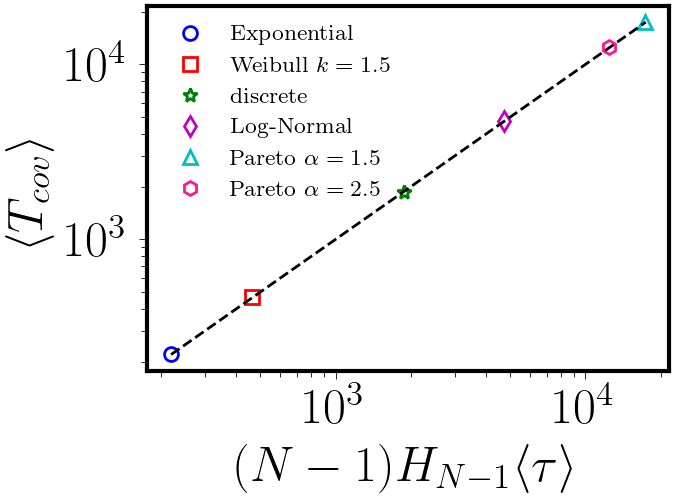

In [141]:

#with open("./data/mean_cover_time.pkl", "rb") as f:
#    results = pickle.load(f)
#df = pd.DataFrame(results)

# Select which distributions to plot
plot_dists = ["exp","weibull","discrete","lognormal","pareto1","pareto2"]
labels = [r'Exponential', r'Weibull $k=1.5$',"discrete", r'Log-Normal',r'Pareto $\alpha=1.5$', r'Pareto $\alpha=2.5$']
markers = ['o', 's', '*', 'd',"^","h"]
colors = ['b', 'r', 'g', 'm',"c","deeppink"]

fig, ax = plt.subplots(figsize=(3.375, 2.5), dpi=200)
for dist, label, marker, color in zip(plot_dists, labels, markers, colors):
    sub = df[df["dist"] == dist]
    #x = sub["theory_mean"].values

    y = sub["empirical_mean"].values
    x = sub["theory_mean"].values

    ax.plot(x[0], y,
            linestyle="None",
            marker=marker,
            markersize=5,
            markerfacecolor="none",   # open markers
            markeredgecolor=color,
            markeredgewidth=1,
            label=label)

# Reference line y = x
min_val = min(df["theory_mean"].min(), df["empirical_mean"].min())
max_val = max(df["theory_mean"].max(), df["empirical_mean"].max())
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="k", linewidth=1)

# Labels
ax.set_xlabel(r" $(N-1)H_{N-1}\langle\tau\rangle$")
ax.set_ylabel(r" $\langle T_{cov}\rangle$")
ax.set_xscale("log")
ax.set_yscale("log")

# Panel label
#ax.text(0.85, 0.15, "(a)", transform=ax.transAxes,
#        fontsize=12, fontweight="bold", va="top")

# Legend
ax.legend(frameon=False, fontsize=8)

plt.tight_layout(pad=0.2)
#plt.savefig("cover_time_scaling.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Save raw data for later use ---
#df.to_csv("cover_time_results.csv", index=False)

In [ ]:


N = 1000                 # graph size
n_walkers = 1000000        # number of simulated walkers (reduce for speed)
rate = 2.0               # lambda
T_fixed = 1
start_node = 0           # starting node index for walkers (0..N-1)
p = 0.1
r,h=3,6
m=4
# Generate connected ER graph
while True:
    G = nx.erdos_renyi_graph(N, p)
    #G = nx.barabasi_albert_graph(N, m,seed=4)
    #G = nx.cycle_graph(N)
    #G = nx.complete_graph(N)
    #G = nx.balanced_tree(r,h)
    if nx.is_connected(G):
        break
start_time = time.time()
nodes, degrees, edges_flat, offsets = preprocess_graph(G)
N=len(G.nodes())
print("degree of 0 node =",G.degree(0))
print("Using graph with N =", N)
# -------------------------
# Run simulation
# -------------------------
start_time = time.time()
C0_hg = 2.0 / (5.0 * np.pi)
dist_types = [0,1, 2, 3]
T_values = [.1,1., 1.0, 1]  # as in your figure
labels = ["Exp", "Half-Gaussian", "Beta(2,2)", "Dagum"]
col=["k--","b--","r--","g--"]
As=[0,0,1,0]
C_As=[rate,C0_hg,6,1]
C_Ap1s=[-(rate**2),0,-6,-2]
scol=["k","b","r","g"]
simcol=["s","o","^","v"]
plt.figure(figsize=(3.675, 2.75),dpi=200)
for dist_type, T, label,A,C_A,C_Ap1 in zip(dist_types, T_values, labels,As,C_As,C_Ap1s):
     
    counts = simulate_distinct_counts(
        T=T,
        n_walkers=10000000000,
        nodes=nodes,
        edges_flat=edges_flat,
        offsets=offsets,
        N=N,
        dist_type=dist_type,
        start_node=0,
        rate=rate
    )
    max_visits = int(np.max(counts))
    v_vals = np.arange(1, max_visits + 1)
    hist = np.bincount(counts, minlength=max_visits + 1)[1:]  # ignore 0
    hist_prob = hist / np.sum(hist)
    Q_ldp_pref, _, _ = Qt_large_dev_logs(T, v_vals-1, A, C_A, C_Ap1, with_prefactor=True)
    # After computing v_vals, hist_prob
    df = pd.DataFrame({
        "S": v_vals[1:],         # skip S=0
        "P_sim": hist_prob[1:],  # simulation
        "P_ld": Q_ldp_pref[1:]   # large deviation prediction
    })

    filename = f"{basepath}/ERD_Qt_dist_n_walkers_{n_walkers}{label}.csv"
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")
    plt.semilogy(v_vals[1:], hist_prob[1:],color=scol[dist_type],linestyle='none',marker=simcol[dist_type],mfc='none', label=label)
    plt.semilogy(v_vals[1:], Q_ldp_pref[1:], col[dist_type], markersize=6)
plt.xlabel(r"$S$")
plt.ylabel(r"$P(S,t)$")
plt.xlim(-0.5, 14.5)
plt.ylim(1e-11, 10.0)
plt.legend(frameon=False,fontsize=10)
plt.tight_layout()
plt.show()

In [116]:
plt.savefig("./fig/mean_cover_time.pdf", dpi=200, format='pdf',
            bbox_inches='tight', pad_inches=0.02)

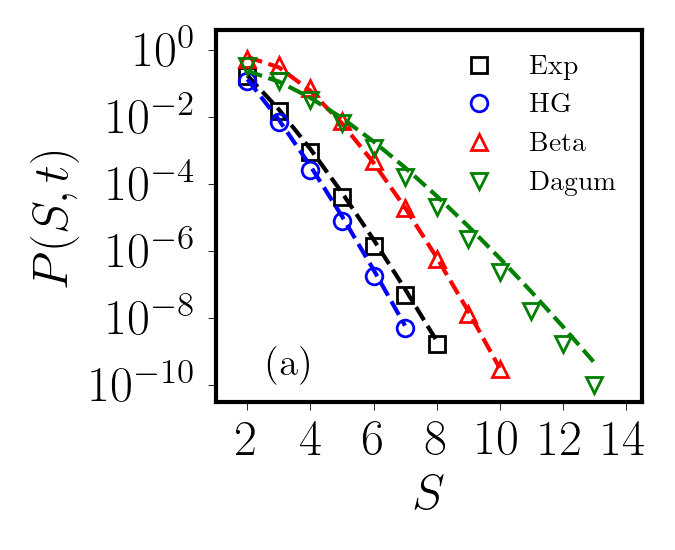

In [90]:
#figure 4
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
i=0
sym=["(a)","(b)","(c)","(d)",]
n_walkers=10000000000
ram=["ERS","BA","ERD","complete_net",]
files = [
    (f"{basepath}/data/{ram[i]}_Qt_dist_n_walkers_{n_walkers}Exp.csv", "k", "s", "Exp"),
    (f"{basepath}/data/{ram[i]}_Qt_dist_n_walkers_{n_walkers}Half-Gaussian.csv", "b", "o", "HG"),
    (f"{basepath}/data/{ram[i]}_Qt_dist_n_walkers_{n_walkers}Beta(2,2).csv", "r", "^", "Beta"),
    (f"{basepath}/data/{ram[i]}_Qt_dist_n_walkers_{n_walkers}Dagum.csv", "g", "v", "Dagum")
]

plt.figure(figsize=(3.375, 2.75), dpi=200)

for fname, col, marker, label in files:
    df = pd.read_csv(fname)
    S = df["S"].values
    P_sim = df["P_sim"].values
    P_ld = df["P_ld"].values

    # Plot simulation
    plt.semilogy(S, P_sim, color=col, linestyle='none', marker=marker,
                 mfc='none', label=label)

    # Plot LD curve
    plt.semilogy(S, P_ld, col + '--')

plt.xlabel(r"$S$")
plt.ylabel(r"$P(S,t)$")
plt.xticks([2,4,6,8,10,12,14])
plt.yticks([1,0.01,0.0001,0.000001,0.00000001,0.0000000001])
plt.xlim(1,14.5)
plt.ylim(0.00000000003,4)
ax=plt.gca()

plt.text(0.12, 0.15, sym[i], transform=ax.transAxes, fontsize=14, va='top')
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(f"./fig/Complete_N_1000_rate_2__walker_{n_walkers}_t_p1_1_1_1_LDP.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [91]:
plt.savefig(f"./fig/ER_N_1000_P_point01_t_point1_rate_2__walker_{n_walkers}_t_p1_1_1_1_LDP.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

In [89]:
plt.savefig(f"./fig/BA_N_1000_m_4_t_point1_rate_2__walker_{n_walkers}_t_p1_1_1_1_LDP0.pdf", format='pdf',
            bbox_inches='tight', pad_inches=0.03)

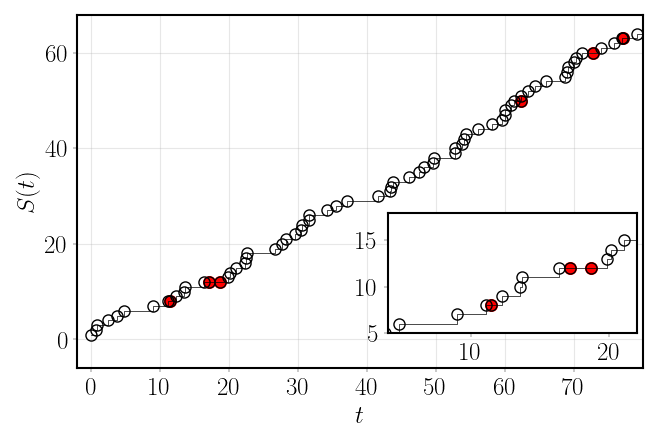

In [100]:

#END MATTER  figure 1
N=1000
data = np.load(f"{basepath}/data/walker_data_ER{N}1.npz")
t_exp = data["t"]
S_exp = data["S"]
plateau_exp = data["plateaus"]

fig, ax = plt.subplots(figsize=(6.575, 4.425))
ax.step(t_exp, S_exp, where='post', color='k', lw=0.5, marker='o',markersize=8, linestyle='-',
        label=r'exponential', mfc='none', mec='k')
ax.scatter(plateau_exp, [S_exp[np.searchsorted(t_exp, pt)] for pt in plateau_exp],
           color='red', s=70, marker='o',)

ax.set_xlabel(r"$t$")
ax.set_ylim(-6,68)
ax.set_xticks([0,10,20,30,40,50,60,70])

ax.set_xlim(-2,80)
ax.set_ylabel(r"$S(t)$")
ax.grid(True, alpha=0.3)
ax_inset = ax.inset_axes([0.55, 0.10, 0.44, 0.34])
ax_inset.step(t_exp, S_exp, color='k',where='post', lw=0.5, marker='o',markersize=8, mfc='none', mec='k')
ax_inset.scatter(plateau_exp, [S_exp[np.searchsorted(t_exp, pt)] for pt in plateau_exp],
        color='red', s=70, marker='o')
ax_inset.set_xlim(4,22)
ax_inset.set_ylim(5,18)
plt.tight_layout()
#plt.savefig("./fig/walker_plateau_plot_t=1_lambda_2_N_1000_co_point1.pdf", dpi=200, format='pdf',
#            bbox_inches='tight', pad_inches=0.02)

In [142]:
def generate_network(network_type, n=100, p=0.6, r=3, h=4, m=3, k=4, nc=[50, 50], seed=1234):
    rng = np.random.default_rng(seed)

    if network_type == 0:  # Fully Connected (FC)
        G = nx.complete_graph(n)

    elif network_type == 1:  # Erdős–Rényi (ER)
        while True:
            G = nx.erdos_renyi_graph(n, p, seed=int(rng.integers(1e9)))
            if nx.is_connected(G):
                break

    elif network_type == 2:  # Barabási–Albert (BA)
        while True:
            G = nx.barabasi_albert_graph(n, m, seed=int(rng.integers(1e9)))
            if nx.is_connected(G):
                break

    elif network_type == 3:  # Small-World (SW)
        while True:
            G = nx.watts_strogatz_graph(n, k, p, seed=int(rng.integers(1e9)))
            if nx.is_connected(G):
                break

    elif network_type == 4:  # Cayley Tree
        
        G = nx.balanced_tree(r, h)

    elif network_type == 5:  # Circular Network
        G = nx.cycle_graph(n)

    elif network_type == 6:  # Two-cluster
        clno = [0, *np.cumsum(nc)]
        G = complete_two_cluster_graph(n, nc, clno)

    else:
        raise ValueError("Invalid network type number")

    return G
@njit
def draw_waiting_time(distribution, lambda_, k, sigma, mu, alpha, x_m):
    if distribution == "exponential":
        return np.random.exponential(1 / lambda_)
    elif distribution == "weibull":
        return np.random.weibull(k) * lambda_
    elif distribution == "lognormal":
        return np.random.lognormal(mu, sigma)
    elif distribution == "pareto1":
        return (np.random.pareto(alpha+1) + 1) * x_m
    elif distribution == "pareto2":
        return (np.random.pareto(alpha+2) + 1) * x_m    
    elif distribution == "pareto":
        return (np.random.pareto(alpha) + 1) * x_m    
    elif distribution == "discrete":
        return 1.0
    else:
        return np.random.exponential(1 / lambda_)

def mean_waiting_time(distribution, lambda_=1.0, k=1.5, sigma=0.5, mu=0.0, alpha=2.5, x_m=1.0):
    """
    Return the mean waiting time ⟨τ⟩ for the given distribution.
    Parameters match those in draw_waiting_time.
    """
    if distribution == "exponential":
        return 1.0 / lambda_

    elif distribution == "weibull":
        # scale * Γ(1 + 1/k), here scale = λ
        return lambda_ * gamma(1.0 + 1.0 / k)

    elif distribution == "lognormal":
        # exp(μ + σ²/2)
        return exp(mu + 0.5 * sigma**2)

    elif distribution == "pareto":
        # standard Pareto mean = (α * xm) / (α - 1), requires α > 1
        return x_m * alpha / (alpha - 1) if alpha > 1 else np.inf

    elif distribution == "pareto1":
        # shape parameter (α+2), mean finite if α+2 > 1
        return x_m * (alpha + 1) / alpha if alpha + 1 > 1 else np.inf
    elif distribution == "pareto2":
        # same as pareto2 in your sampler
        return x_m * (alpha + 2) / (alpha + 1) if alpha + 2 > 1 else np.inf

    elif distribution == "discrete":
        return 1.0

    else:
        # default: exponential
        return 1.0 / lambda_
import numpy as np
from math import gamma, exp, inf

# ======================
# Cover time simulation
# ======================
@njit(parallel=True)
def simulate_cover_times(n_rounds, nodes, offsets, edges_flat, N,
                         distribution, lambda_, k, sigma, mu, alpha, x_m):
    cover_times = np.empty(n_rounds, dtype=np.float64)
    mean_waitings = np.empty(n_rounds, dtype=np.float64)
    for i in prange(n_rounds):
        current = np.random.randint(N)
        visited = np.zeros(N, dtype=np.int8)
        visited[current] = 1
        distinct = 1
        t = 0.0
        tau_sum = 0.0
        tau_count = 0

        while distinct < N:
            tau = draw_waiting_time(distribution, lambda_, k, sigma, mu, alpha, x_m)
            t += tau
            tau_sum += tau
            tau_count += 1

            start, end = offsets[current], offsets[current + 1]
            current = edges_flat[start + np.random.randint(end - start)]
            if visited[current] == 0:
                visited[current] = 1
                distinct += 1

        cover_times[i] = t
        mean_waitings[i] = tau_sum / tau_count  # average waiting time in this run

    return cover_times, mean_waitings


node_sizes = [50, 100, 300, 600, 800,1000]
dists = ["exp","weibull","discrete","lognormal","pareto1","pareto2"]
labels = [r'Exponential', r'Weibull $k=1.5$', "Discrete",r'Log-Normal', r'Pareto $\alpha=1.5$',r'Pareto $\alpha=2.5$']
markers = ['o', 's', '*', 'd',"^","h"]
colors = ['b', 'r', 'g', 'm',"c","p"]
# parameters
lambda_ ,k,sigma,alpha,mu,x_m,n_rounds= 1.0,1.5,0.5,0.5,0,1.0,1000


dists = ["pareto"]
alphas=[0.1,0.2,0.4,0.6,0.8,0.9]
np.random.seed(0)
results = []
i=0
for N in tqdm(node_sizes):
    dist=dists[0]
    G = generate_network(network_type=0, n=N)  # 0 == complete
    nodes, degrees, edges_flat, offsets, E = preprocess_graph(G)
    cover_times,tau_mean = simulate_cover_times(
                n_rounds, nodes, offsets, edges_flat, N,
                dist, lambda_, k, sigma, mu, alphas[i], x_m
            )
    empirical_mean = np.mean(cover_times)
    tau_mean1 = np.mean(tau_mean)
     
    theory_tau_mean=mean_waiting_time(dist,alpha=alphas[i],lambda_=1.0, k=1.5, sigma=0.5, mu=0.0, x_m=1.0)
    H = harmonic_number(N)
    theory_mean1 = (N - 1) * H * theory_tau_mean
    theory_mean2 = (N - 1) * H * tau_mean1 
    results.append({
                "dist": dist,
                "N": N,
                "empirical_mean": empirical_mean,
                "theory_mean": theory_mean1,
                "tau_mean": theory_mean2,
                "H": H,
            })
    i=i+1
df = pd.DataFrame(results)
#with open("./data/mean_cover_time.pkl", "wb") as f:
#    pickle.dump(results, f)

print("✅ Results saved to simulation_results.pkl")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:06<00:00,  1.11s/it]

✅ Results saved to simulation_results.pkl


In [143]:
df

,dist,N,empirical_mean,theory_mean,tau_mean,H
0,pareto,50,2.071989e+50,inf,3.131442e+50,4.479205
1,pareto,100,1.395916e+28,inf,2.246415e+28,5.177378
2,pareto,300,3.612230e+13,inf,4.286656e+13,6.279331
3,pareto,600,9.711982e+08,inf,1.048997e+09,6.973312
4,pareto,800,3.932325e+06,inf,4.825308e+06,7.261202
5,pareto,1000,3.994606e+05,inf,3.572954e+05,7.484471


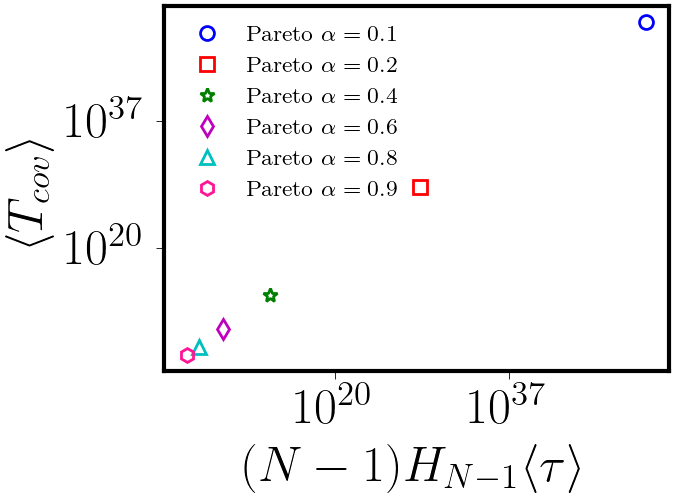

In [144]:
#with open("./data/mean_cover_time.pkl", "rb") as f:
#    results = pickle.load(f)
#df = pd.DataFrame(results)

# Select which distributions to plot
labels = [r'Pareto $\alpha=0.1$',r'Pareto $\alpha=0.2$',r'Pareto $\alpha=0.4$', r'Pareto $\alpha=0.6$', r'Pareto $\alpha=0.8$',r'Pareto $\alpha=0.9$']
markers = ['o', 's', '*', 'd',"^","h"]
colors = ['b', 'r', 'g', 'm',"c","deeppink"]
node_sizes = [50, 100, 300, 600, 800,1000]
fig, ax = plt.subplots(figsize=(3.375, 2.5), dpi=200)
for N, label, marker, color in zip(node_sizes, labels, markers, colors):
    sub = df[df["N"] == N]
    #x = sub["theory_mean"].values

    y = sub["empirical_mean"].values
    x = sub["tau_mean"].values

    ax.plot(x[0], y,
            linestyle="None",
            marker=marker,
            markersize=5,
            markerfacecolor="none",   # open markers
            markeredgecolor=color,
            markeredgewidth=1,
            label=label)

# Reference line y = x
min_val = min(df["theory_mean"].min(), df["empirical_mean"].min())
max_val = max(df["theory_mean"].max(), df["empirical_mean"].max())
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="k", linewidth=1)

# Labels
ax.set_xlabel(r" $(N-1)H_{N-1}\langle\tau\rangle$")
ax.set_ylabel(r" $\langle T_{cov}\rangle$")
ax.set_xscale("log")
ax.set_yscale("log")

# Panel label
#ax.text(0.85, 0.15, "(a)", transform=ax.transAxes,
#        fontsize=12, fontweight="bold", va="top")

# Legend
ax.legend(frameon=False, fontsize=8)

plt.tight_layout(pad=0.2)
#plt.savefig("cover_time_scaling.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Save raw data for later use ---
#df.to_csv("cover_time_results.csv", index=False)